In [4]:
import pandas as pd
from dotenv import load_dotenv
import os 

In [5]:
import sys
sys.path.append("..")

In [6]:
from utils.get_market_data import get_candles

In [43]:
from datetime import datetime, timedelta, timezone
now = datetime.now()
from_ = now - timedelta(days=90)
sber_price = get_candles("SBER", from_, now, interval=1)
sber_price.head()

Number of deleted duplicates: 0


,open,close,high,low,value,volume,end
timestamp,,,,,,,
2026-02-20 14:41:00,313.61,313.57,313.61,313.49,5218149.43,16643,2026-02-20 14:41:59
2026-02-20 14:42:00,313.57,313.63,313.64,313.51,6029402.75,19227,2026-02-20 14:42:59
2026-02-20 14:43:00,313.57,313.63,313.63,313.57,263117.47,839,2026-02-20 14:43:59
2026-02-20 14:44:00,313.63,313.59,313.63,313.59,349364.84,1114,2026-02-20 14:44:59
2026-02-20 14:45:00,313.59,313.61,313.61,313.56,1610652.63,5136,2026-02-20 14:45:59


In [44]:
load_dotenv()
db_url = os.getenv("DB_URL")

In [58]:
import psycopg2

conn = psycopg2.connect(db_url)
cur = conn.cursor()

ticker = "SR320CD6"
strike = 320
expiry_date = datetime(2026, 4, 15, 19, tzinfo=timezone.utc)

cur.execute("""
SELECT timestamp, bids, asks FROM orderbooks
WHERE ticker = %s
""", (ticker,))

rows = cur.fetchall()

In [112]:
df = pd.DataFrame(rows, columns=['timestamp', 'bids', 'asks'])
df.head(1)

,timestamp,bids,asks
0,2026-03-23 16:00:36+00:00,"[{'price': 5.0, 'quantity': 15}, {'price': 4.6...","[{'price': 6.86, 'quantity': 800}, {'price': 8..."


In [113]:
df['best_bid'] = df['bids'].apply(lambda x: x[0]['price'] if x else None)
df['best_ask'] = df['asks'].apply(lambda x: x[0]['price'] if x else None)

df['mid'] = ((df['best_ask'] + df['best_bid']) / 2).fillna(df['best_ask']).fillna(df['best_bid'])
df = df[['timestamp', 'best_bid', 'best_ask', 'mid']]
df.head(1)

,timestamp,best_bid,best_ask,mid
0,2026-03-23 16:00:36+00:00,5.0,6.86,5.93


In [114]:
df['time_to_expiry'] = df['timestamp'].apply(lambda x: (expiry_date - x).total_seconds()/31536000)
df.head(1)

,timestamp,best_bid,best_ask,mid,time_to_expiry
0,2026-03-23 16:00:36+00:00,5.0,6.86,5.93,0.063355


In [115]:
sber_price_df = sber_price[['close']]
sber_price_df.head(5)

,close
timestamp,
2026-02-20 14:41:00,313.57
2026-02-20 14:42:00,313.63
2026-02-20 14:43:00,313.63
2026-02-20 14:44:00,313.59
2026-02-20 14:45:00,313.61


In [117]:
sber_price_df['merge_time'] = sber_price_df.index
sber_price_df['merge_time'] = sber_price_df['merge_time'].dt.tz_localize('UTC')
sber_price_df = sber_price_df.sort_values('merge_time')
df = df.sort_values('timestamp')


merged_df = pd.merge_asof(
    df,
    sber_price_df,
    left_on = "timestamp",
    right_on = "merge_time"
)

merged_df.head()

,timestamp,best_bid,best_ask,mid,time_to_expiry,close,merge_time
0,2026-03-23 15:50:01+00:00,5.0,8.81,6.905,0.063375,317.09,2026-03-23 15:50:00+00:00
1,2026-03-23 15:50:01+00:00,5.0,8.81,6.905,0.063375,317.09,2026-03-23 15:50:00+00:00
2,2026-03-23 15:50:01+00:00,5.0,8.81,6.905,0.063375,317.09,2026-03-23 15:50:00+00:00
3,2026-03-23 16:00:36+00:00,5.0,6.86,5.930,0.063355,317.1,2026-03-23 16:00:00+00:00
4,2026-03-23 16:03:45+00:00,5.0,8.81,6.905,0.063349,317.04,2026-03-23 16:03:00+00:00


In [120]:
from utils.iv_solver import iv_newton

def exception_iv(row):
    try:
        return iv_newton(
            row.close, 
            strike, 
            0.13, 
            row.time_to_expiry, 
            row.mid, 
            "CALL",
            0.0001 , 
            100
        )
    except ValueError as e:
        print(e)
        return None
        

merged_df['IV'] = merged_df.apply(lambda row: exception_iv(row), axis=1)
merged_df.head(1)

Backup bisection method is not applicable
Backup bisection method is not applicable
Backup bisection method is not applicable
Backup bisection method is not applicable
Backup bisection method is not applicable
Backup bisection method is not applicable
Backup bisection method is not applicable
Backup bisection method is not applicable
Backup bisection method is not applicable
Backup bisection method is not applicable


,timestamp,best_bid,best_ask,mid,time_to_expiry,close,merge_time,IV
0,2026-03-23 15:50:01+00:00,5.0,8.81,6.905,0.063375,317.09,2026-03-23 15:50:00+00:00,0.221192


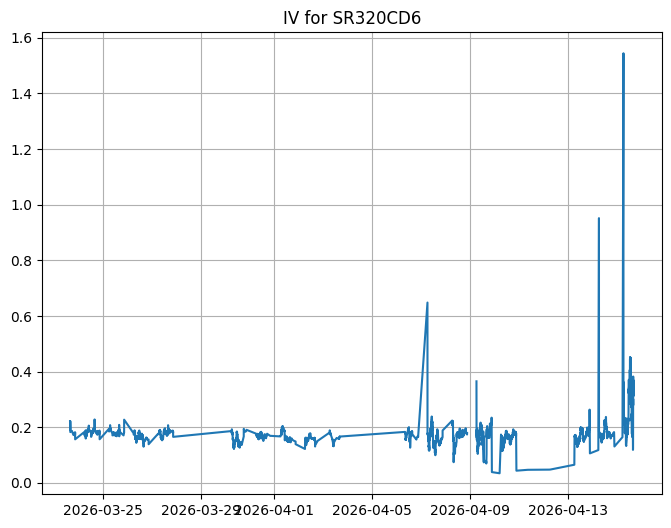

In [128]:
from matplotlib import pyplot as plt

fig = plt.figure(figsize=(8,6))

plt.plot(merged_df['timestamp'], merged_df['IV'])
plt.title(f"IV for {ticker}")
plt.grid()